# Анализ и прогнозирование данных платежей

Анализируем данные по платежам от донорров в адрес фондов, прогнозируем суммы платежей в различных формах - каждый из платежей в отдельности по описательным признакам, суммы платежей суммарно на следующей неделе, следующем месяце, а также на несколько временных отрезков вперед, также с группировкой по различным описательным признакам (фонды, провайдеры платежей, тип подписки, категории платежей).

На **данном этапе** данные подготовлены для прогнозирования сумм исходя из описательных признаков - без учета временной составляющей и группировки по признакам, общая модель на всех данных, которая прогнозирует сумму платежа. Данный пункт будет дополняться.

<a id='К-содержанию'></a>
**Содержание проекта** \
[Загрузка и предобработка данных](#Загрузка-и-предобработка-данных)\
[Иследовательский анализ данных](#Исследовательский-анализ-данных)\
[Подготовка данных и обучение наивной модели прогнозирования сумм платежей](#Подготовка-данных-и-обучение-наивной-модели-прогнозирования-сумм-платежей)

In [1]:
%%capture
!pip install catboost
!pip install category_encoders

In [2]:
#импортируем библиотеки перед началом проекта одним блоком
import os
import pandas as pd
import numpy as np
import random
import re
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# загружаем класс pipeline и классы дя подготовки данных и запуска пайплайна
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from tqdm import notebook
from category_encoders.target_encoder import TargetEncoder
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# загружаем нужные модели и метрики
from sklearn.linear_model import LinearRegression, Ridge
from catboost import CatBoostRegressor
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error

# загружаем библиотеки для Pytorch и предобученных моделей
import torch
from torch import nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [3]:
# вынесем блок с настройками и функциями

# зададим стандарт датафрейма перед загрузкой
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('future.no_silent_downcasting', True)

# устанавливаем фиксированное значение для всех случайных библиотек
RANDOM_STATE = 42

def seed_all(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False
seed_all(RANDOM_STATE)

# вывод гистограммы и boxplot
def hist_box(data,column,hue=None):
    
    palette = sns.color_palette('hsv', n_colors=10)
    random_color = random.choice(palette)
    
    if hue == None:
        
        fig, axes = plt.subplots(1, 2, figsize=(7, 2)) 
        ax = axes[0]
        sns.histplot(data=data, x=column, bins=10, 
                     color=random_color,
                     alpha=0.6,
                     legend='auto', ax=ax)
    else:
        fig, axes = plt.subplots(1, 2, figsize=(7, 2)) 
        ax = axes[0]
        sns.histplot(data=data, x=column, bins=10, 
                     color=random_color,
                     alpha=0.6,
                     hue=hue, 
                     multiple='stack',
                     legend='auto', ax=ax)
        

    ax = axes[1]
    sns.boxplot(x=data[column], color=random_color, ax=ax)
    ax.set_ylabel('')

    plt.tight_layout()
    plt.show();

<a id='Загрузка-и-предобработка-данных'></a> 
## Загрузка и предобработка данных
[К содержанию](#К-содержанию)

In [4]:
# импортируем тренировочные данные
pth1 = 'data.csv'

if os.path.exists(pth1):
    data = pd.read_csv(pth1)
else:
    print('Something is wrong')

data.info()
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360258 entries, 0 to 360257
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   fund_id     360258 non-null  int64  
 1   full_sum    360258 non-null  float64
 2   date        360258 non-null  int64  
 3   provider    360258 non-null  int64  
 4   signup      360258 non-null  int64  
 5   category_1  360258 non-null  int64  
 6   category_2  360258 non-null  int64  
 7   category_3  360258 non-null  int64  
 8   category_4  360258 non-null  int64  
 9   category_5  360258 non-null  int64  
 10  category_6  360258 non-null  int64  
 11  category_7  360258 non-null  int64  
dtypes: float64(1), int64(11)
memory usage: 33.0 MB


,fund_id,full_sum,date,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7
0,44,500.00,1508393717,4,0,0,0,0,0,0,0,0
1,88,200.00,1508399528,4,0,0,0,0,0,0,0,0
2,1,100.00,1508400025,4,0,0,0,0,0,0,0,0
3,1,100.00,1508400043,4,0,0,0,0,0,0,0,0
4,1,20.00,1508400088,4,0,0,0,0,0,0,0,0


In [5]:
# посмотрим распределение меток по категориям
cat_columns = ['category_1', 'category_2', 'category_3', 'category_4', 'category_5', 'category_6', 'category_7']

data['cat_columns_sum'] = data[cat_columns].sum(axis=1)
data['cat_columns_sum'].value_counts()

cat_columns_sum
0    321861
1     21656
2     10219
3      6522
Name: count, dtype: int64

In [6]:
# проверим дубликаты
print('Количество дубликатов: ', data.duplicated().sum().sum())

# проверим пропуски
print('Количество пропусков: ', data.isna().sum().sum())

# уберем дубликаты и пропуски
data = data.drop_duplicates()
data = data.dropna()

Количество дубликатов:  2989
Количество пропусков:  0


Выловили порядка 3 тысяч дубликатов, что с одной стороны маловероятно - одинаковые платежи в одну и ту же секунду, но, возможно, банк обработал платежи одним пакетом, с точки зрения обучения дубликаты не несут дополнительной информации, поэтому их удалили.

Также видно, что количество строк без меток в категориях составляет порядка 90%, возиожно необходимр будет дополнительно обработать эти данные.

<a id='Исследовательский-анализ-данных'></a> 
## Исследовательский анализ данных
[К содержанию](#К-содержанию)

В данном разделе собрал некоторые потенциально интересные представления данных. Это не полноценный факторный анализ, т.к. цель была в первую очередь выявить и убрать аномалии, выбросы. В дальнейшем раздел будем дополнять по мере изучения данных.

Посмотрим немного на распределения данных, проверим аномалии: 

Всего фондов-получателей в выборке: 188
Топ-6 фондов получили: 235398 платежей по количеству или 65.89% от общего числа платежей


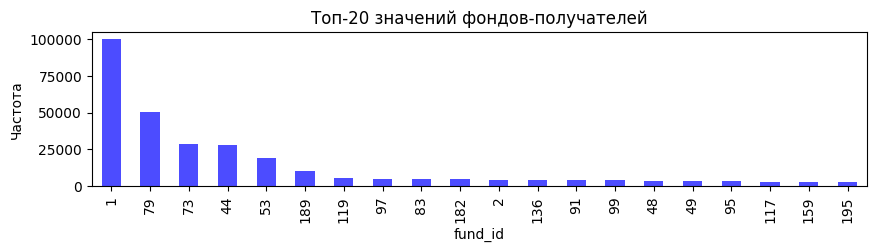

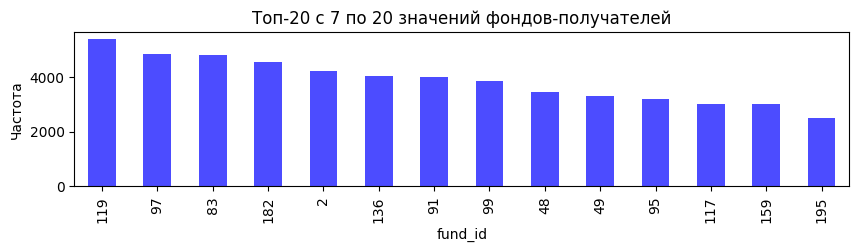

In [7]:
# посмотрим распределение записей по фондам (возьмем топ-20)
print('Всего фондов-получателей в выборке:',data['fund_id'].nunique())

value_counts = data['fund_id'].value_counts(ascending=False)
top_20 = value_counts.head(20)
top_6 = value_counts.head(6)
print('Топ-6 фондов получили:', top_6.sum(), 'платежей по количеству или', f"{top_6.sum()/data.shape[0]*100:.2f}%", 'от общего числа платежей')

# строим барплот
plt.figure(figsize=(10, 2))
top_20.plot(kind='bar', color='blue', alpha=0.7)
plt.title("Топ-20 значений фондов-получателей")
plt.xlabel("fund_id")
plt.ylabel("Частота")
plt.xticks(rotation=90)
plt.show()

# возьмем количество поступлений фондам с 7 по 20 в топ-20
top_7_to_20 = value_counts.iloc[6:20]
# строим барплот
plt.figure(figsize=(10, 2))
top_7_to_20.plot(kind='bar', color='blue', alpha=0.7)
plt.title("Топ-20 с 7 по 20 значений фондов-получателей")
plt.xlabel("fund_id")
plt.ylabel("Частота")
plt.xticks(rotation=90)
plt.show()

In [8]:
# посмотрим на распределение по суммам платежей
description = data['full_sum'].describe()
percentiles = data['full_sum'].quantile([0.8, 0.9, 0.99, 0.999])
detailed_description = pd.concat([description, percentiles.rename('percentiles')])
print(detailed_description)

 count    357269.00
 mean        445.57
 std       12452.02
 min           2.00
 25%         100.00
 50%         100.00
 75%         500.00
 max     5555898.84
0.80         500.00
0.90        1000.00
0.99        3001.00
1.00       10000.00
dtype: float64


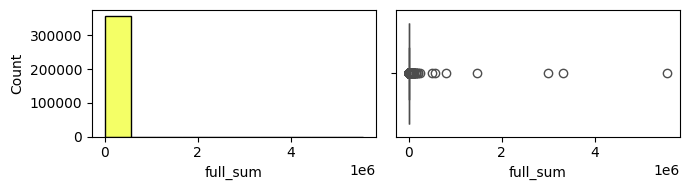

In [9]:
# построим гистограммку и боксплот
hist_box(data,'full_sum')

In [10]:
# по суммам 99% платежей менее 3000 рублей, есть несколько выбросов, посмотрим на платежи более 3 тысяч рублей
data_ext_sum = data[data['full_sum']>3000]
print('Количество платежей на сумму более 3000 руб.:', data_ext_sum['full_sum'].count())
#data_ext_sum

Количество платежей на сумму более 3000 руб.: 3583


In [11]:
# так платежей более 3 тысяч рублей около 3000, включая мегавыбросы в несколько миллионов рублей, предлагается их исключить 
# для более адекватного обучения модели 

data = data[data['full_sum']<=3000]

In [12]:
# по датам добавим столбец в наглядном формате datetime
data['datetime'] = pd.to_datetime(data['date'], unit='s')
data.head() 

,fund_id,full_sum,date,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,cat_columns_sum,datetime
0,44,500.00,1508393717,4,0,0,0,0,0,0,0,0,0,2017-10-19 06:15:17
1,88,200.00,1508399528,4,0,0,0,0,0,0,0,0,0,2017-10-19 07:52:08
2,1,100.00,1508400025,4,0,0,0,0,0,0,0,0,0,2017-10-19 08:00:25
3,1,100.00,1508400043,4,0,0,0,0,0,0,0,0,0,2017-10-19 08:00:43
4,1,20.00,1508400088,4,0,0,0,0,0,0,0,0,0,2017-10-19 08:01:28


count                           353686
mean     2018-04-24 07:45:45.910415104
min                2017-10-19 06:15:17
25%      2018-01-29 10:55:43.750000128
50%                2018-04-28 14:35:02
75%         2018-07-25 22:08:52.500000
max                2018-10-19 12:25:24
Name: datetime, dtype: object

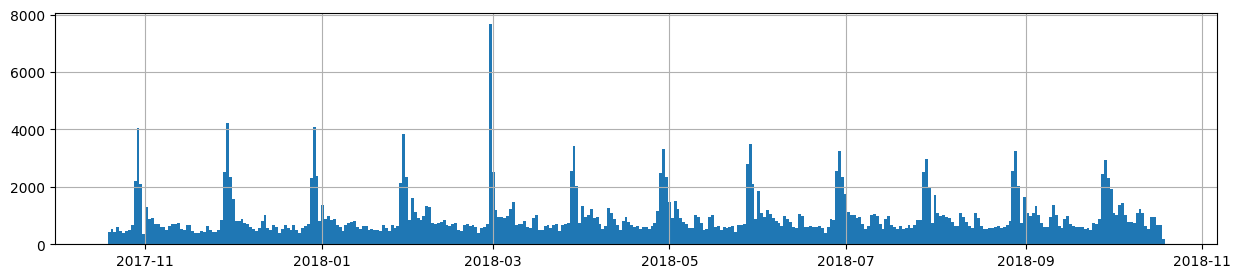

In [13]:
# посмотрим на распределение по датам и платежам
display(data['datetime'].describe())
data['datetime'].dt.date.hist(bins=366, figsize=(15, 3));

In [14]:
# глянем на распределение количества платежей по провайдерам и типам подписки
print('Распределение количества платежей по типу провайдера:')
for provider, count in data['provider'].value_counts().items():
    print(provider, count)

print('\nРаспределение количества платежей по типу подписки:')
for signup, count in data['signup'].value_counts().items():
    print(signup, count)

Распределение количества платежей по типу провайдера:
1 323433
5 16738
4 11316
3 2196
9 3

Распределение количества платежей по типу подписки:
1 302786
0 50900


In [15]:
# проверим корректность набора меток категорий, которые должны быть одинаковыми для каждого фонда (там где метки в принципе есть)
data.groupby('fund_id')[cat_columns].sum()

,category_1,category_2,category_3,category_4,category_5,category_6,category_7
fund_id,,,,,,,
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0
37,0,0,0,0,0,0,0
43,0,0,0,0,0,0,0
44,0,0,0,0,0,0,0
48,0,0,0,0,0,0,0
49,0,0,0,0,0,0,0
53,0,0,0,0,0,0,0
55,0,0,0,0,0,0,0


Из того, что удалось сразу увидеть: 66% платежей приходится на топ-6 фондов, 99% платежей на сумму до 3000 рублей, значительных пожертвований на сумму более 3 тысяч рублей также около 3000, из них несколько аномально больших на сумму более 1 млн рублей - выбросы удалили, т.к. это поможет модели лучше прогнозировать наиболее частые небольшие платежи.

Распределение полатежей по датам очевидно привязно к получению ЗП, премий с пиками на последние дни месяца и особенным пиком в конце 1 кв. года (обычно выплата годовой премии).

90% платежей поступают через провайдера 1, и доля регулярных пожертвований также подавляющая - 85%.

Также подтвердили гипотезу, что метки категорий платежей у каждого фонда постоянны (там, где метки в принципе проставлены).

<a id='Подготовка-данных-и-обучение-наивной-модели прогнозирования сумм платежей'></a> 
## Подготовка данных и обучение наивной модели прогнозирования сумм платежей
[К содержанию](#К-содержанию)

Разделим данные и попробуем добавить немного признаков для обогащения датасета:

In [16]:
# разделим выборку на тренировочную и тестовую
X_train, X_test, y_train, y_test = train_test_split(
    data,
    #data.drop('full_sum', axis=1),
    data['full_sum'],
    test_size=0.25,
    random_state=RANDOM_STATE
    #stratify=data_train_filtered['fund_id']
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# проверим размерности после разбивки
print('Размерности датасетов после разбивки: \n',
    X_train.shape,
    X_test.shape,
    y_train.shape,
    y_test.shape)


Размерности датасетов после разбивки: 
 (265264, 14) (88422, 14) (265264,) (88422,)


In [17]:
X_train.head()

,fund_id,full_sum,date,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,cat_columns_sum,datetime
0,48,100.00,1538395583,1,1,0,0,0,0,0,0,0,0,2018-10-01 12:06:23
1,213,1000.00,1531486619,1,0,0,0,0,0,0,0,0,0,2018-07-13 12:56:59
2,189,100.00,1536930304,1,1,0,0,0,0,0,0,0,0,2018-09-14 13:05:04
3,104,500.00,1537119736,1,0,1,0,1,0,0,0,0,2,2018-09-16 17:42:16
4,44,50.00,1509278129,1,1,0,0,0,0,0,0,0,0,2017-10-29 11:55:29


In [18]:
X_test.head()

,fund_id,full_sum,date,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,cat_columns_sum,datetime
0,44,100.00,1522157403,1,1,0,0,0,0,0,0,0,0,2018-03-27 13:30:03
1,79,100.00,1531153526,1,1,0,0,0,0,0,0,0,0,2018-07-09 16:25:26
2,49,500.00,1519857606,1,1,0,0,0,0,0,0,0,0,2018-02-28 22:40:06
3,44,500.00,1528334743,1,0,0,0,0,0,0,0,0,0,2018-06-07 01:25:43
4,44,50.00,1538297719,1,1,0,0,0,0,0,0,0,0,2018-09-30 08:55:19


In [19]:
#создаем ноые признаки

def add_data(X):
    # временные метки платежей из столбца datetime
    X['hour'] = X['datetime'].dt.hour
    X['day'] = X['datetime'].dt.day
    X['weekday'] = X['datetime'].dt.weekday

    # среднее за последние 7 платежей для каждого fund_id
    X['fund_recent_payment'] = X.groupby('fund_id')['full_sum'].shift(1).rolling(window=7).sum().reset_index(level=0, drop=True)
    
    # средние значения по провайдерам
    X['provider_avg_payment_regular'] = X[X['signup'] == 1].groupby('provider')['full_sum'].transform('mean')
    X['provider_avg_payment_one_time'] = X[X['signup'] == 0].groupby('provider')['full_sum'].transform('mean')

    # забиваем NaN нулями (если есть) средним значениям провайдеров
    X.fillna({'provider_avg_payment_regular': 0}, inplace=True)
    X.fillna({'provider_avg_payment_one_time': 0}, inplace=True)

    # средние значения по fund_id
    X['fund_avg_payment'] = X.groupby('fund_id')['full_sum'].transform('mean')
    X['fund_regular_payment_ratio'] = X.groupby('fund_id')['signup'].transform('mean')
    X['fund_payment_count'] = X.groupby('fund_id')['full_sum'].transform('count')

    return X

# применяем функцию генерации признаков к X_train и X_test
X_train_added = add_data(X_train)
X_test_added = add_data(X_test)


In [20]:
X_train_added.head()

,fund_id,full_sum,date,provider,signup,category_1,category_2,category_3,category_4,category_5,category_6,category_7,cat_columns_sum,datetime,hour,day,weekday,fund_recent_payment,provider_avg_payment_regular,provider_avg_payment_one_time,fund_avg_payment,fund_regular_payment_ratio,fund_payment_count
0,48,100.00,1538395583,1,1,0,0,0,0,0,0,0,0,2018-10-01 12:06:23,12,1,0,NaN,273.19,0.00,422.05,0.72,2571
1,213,1000.00,1531486619,1,0,0,0,0,0,0,0,0,0,2018-07-13 12:56:59,12,13,4,NaN,0.00,621.26,470.14,0.53,1778
2,189,100.00,1536930304,1,1,0,0,0,0,0,0,0,0,2018-09-14 13:05:04,13,14,4,NaN,273.19,0.00,155.36,0.90,7798
3,104,500.00,1537119736,1,0,1,0,1,0,0,0,0,2,2018-09-16 17:42:16,17,16,6,NaN,0.00,621.26,314.71,0.50,122
4,44,50.00,1509278129,1,1,0,0,0,0,0,0,0,0,2017-10-29 11:55:29,11,29,6,NaN,273.19,0.00,220.43,0.95,20631


In [21]:
# уберем лишние столбцы и целевой (мы на его основе делали скользящее среднее - не включая текущий платеж, чтобыне было ликов)
X_train_added = X_train_added.drop(['date', 'datetime','cat_columns_sum','full_sum'], axis=1)
X_test_added = X_test_added.drop(['date', 'datetime','cat_columns_sum','full_sum'], axis=1)


In [22]:
# формируем пайплайн для подготовки данных
# создаём списки с названиями признаков
target_encode_columns = ['fund_id', 'provider']
ohe_columns = ['hour', 'day', 'weekday']
scale_columns = ['fund_recent_payment',
                 'provider_avg_payment_regular',
                 'provider_avg_payment_one_time',
                 'fund_avg_payment',
                 'fund_payment_count']

# кодируем категории TargetEncoder (вне пайплайна, тюкю требуется передать целевой признак)
encoder = TargetEncoder(cols=target_encode_columns)
X_train_encoded = encoder.fit_transform(X_train_added, y_train)
X_test_encoded = encoder.transform(X_test_added)

# пайплайн для кодирования OneHotEncoder
ohe_pipe = Pipeline([
    ('ohe', OneHotEncoder(drop='first', sparse_output=False))
])

# пайплайн для масштабирования численных столбцов
scale_pipe = Pipeline([
    ('scaler', StandardScaler())
])

# общий пайплайн дя подготовки данных
preprocessor = ColumnTransformer([
    ('one_hot_encode', ohe_pipe, ohe_columns),
    ('scaling', scale_pipe, scale_columns)
], remainder='passthrough')

# делаем подготовку данных
X_train_encoded = preprocessor.fit_transform(X_train_encoded)
X_test_encoded = preprocessor.transform(X_test_encoded)

# приводим назад X_train и X_test к DataFrame
X_train_encoded = pd.DataFrame(X_train_encoded, columns=preprocessor.get_feature_names_out())
X_test_encoded = pd.DataFrame(X_test_encoded, columns=preprocessor.get_feature_names_out())

In [23]:
# удаляем строки с пропусками (из-за скользящего среднего по поступлениям)
X_train_encoded = X_train_encoded.dropna()
X_test_encoded = X_test_encoded.dropna()
y_train = y_train.loc[X_train_encoded.index]
y_test = y_test.loc[X_test_encoded.index]

In [24]:
display(X_train_encoded.shape,
        y_train.shape,
        X_test_encoded.shape,
        y_test.shape)

(264202, 75)

(264202,)

(87416, 75)

(87416,)

In [25]:
# создаём итоговый пайплайн с выбором модели и гиперпараметров для обучения
pipe_final = Pipeline([
    ('models', Ridge())
])

# Задаем наборы гиперпараметров для перебора
param_grid = [
    # Словарь для модели Ridge
    {
        'models': [Ridge()],
        'models__alpha': [0.1, 1.0, 10.0]
    },
    
    # Словарь для модели CatBoostRegressor
    {
        'models': [CatBoostRegressor(silent=True, random_state=RANDOM_STATE)],
        'models__depth': [7],
        'models__iterations': [500],
        'models__learning_rate': [0.1],
        'models__l2_leaf_reg': [3]
    },
]

In [26]:
flag = 0

In [27]:
# полный перебор гиперпараметров с помощью GridSearchCV с применением tqdm

param_grid = ParameterGrid(param_grid)  # параметры для перебора внутри tqdm

if flag != 1:
    # настройка tqdm
    total_combinations = len(param_grid)
    with tqdm(total=total_combinations) as pbar:
        best_rmse = float('inf')
        best_r2 = -float('inf')
        best_params = None
        best_model = None

        for params in param_grid:
            grid_search = GridSearchCV(
                pipe_final,
                {k: [v] for k, v in params.items()},  # подставляем конкретный набор параметров
                cv=5,
                scoring=['neg_mean_squared_error', 'r2'],
                refit='neg_mean_squared_error',
                n_jobs=-1,
            )
            model = grid_search.fit(X_train_encoded, y_train)

            # выводим все метрики для текущей комбинации параметров
            for scorer in ['neg_mean_squared_error', 'r2']:
                if scorer == 'neg_mean_squared_error':
                    # вычисляем и выводим RMSE
                    mse_value = -model.cv_results_[f"mean_test_{scorer}"]
                    rmse_value = np.sqrt(mse_value)
                    print(f'Метрика RMSE: {rmse_value}')

                    # обновляем RMSE(если он улучшился) и обновляем R2
                    if rmse_value < best_rmse:
                        best_rmse = rmse_value
                        best_r2 = model.cv_results_[f"mean_test_r2"]
                        best_params = model.best_params_
                        best_model = model.best_estimator_

                else:
                    # выводим R2
                    r2_value = model.cv_results_[f"mean_test_{scorer}"]
                    print(f'Метрика {scorer}: {r2_value}')

            print(f'Параметры модели: {model.best_params_}\n')

            pbar.update(1)  # обновляем прогресс бар tqdm

    # лучшие метрики RMSE и R2 и параметры модели
    print(f'Лучший RMSE: {best_rmse}')
    print(f'Лучший R²: {best_r2}')
    print(f'Параметры лучшей модели: {best_params}')

  0%|          | 0/4 [00:00<?, ?it/s]

Метрика RMSE: [391.09696008]
Метрика r2: [0.12270093]
Параметры модели: {'models': Ridge(), 'models__alpha': 0.1}

Метрика RMSE: [391.09699823]
Метрика r2: [0.12270082]
Параметры модели: {'models': Ridge(), 'models__alpha': 1.0}

Метрика RMSE: [391.10381132]
Метрика r2: [0.12267065]
Параметры модели: {'models': Ridge(), 'models__alpha': 10.0}

Метрика RMSE: [381.255728]
Метрика r2: [0.16628854]
Параметры модели: {'models': <catboost.core.CatBoostRegressor object at 0x317e8add0>, 'models__depth': 7, 'models__iterations': 500, 'models__l2_leaf_reg': 3, 'models__learning_rate': 0.1}

Лучший RMSE: [381.255728]
Лучший R²: [0.16628854]
Параметры лучшей модели: {'models': <catboost.core.CatBoostRegressor object at 0x317e8add0>, 'models__depth': 7, 'models__iterations': 500, 'models__l2_leaf_reg': 3, 'models__learning_rate': 0.1}


In [28]:
# проверим работу модели на тестовой выборке
y_test_pred = best_model.predict(X_test_encoded)
print(f'Метрика RMSE на тестовой выборке: {round(np.sqrt(mean_squared_error(y_test, y_test_pred)),3)}')

Метрика RMSE на тестовой выборке: 385.361


**Вывод**

Простая модель catboost на всех исходных и дополнительных признаках, показала метрику RMSE на кросс-валидации на уровне 381 рублей с метрикой R2 на уровне 17%, и столько же примерно на тестовой выборке (385 рубля), что при среднем платеже в 100 рублей явно маловато. Далее предлагается прогнозировать более агрегированные данные (на неделю, месяц), в том числе с учетом временной составляющей и с группировкой по разным признакам. 